🧠 EMOTIONAL DRIFT ANALYSIS


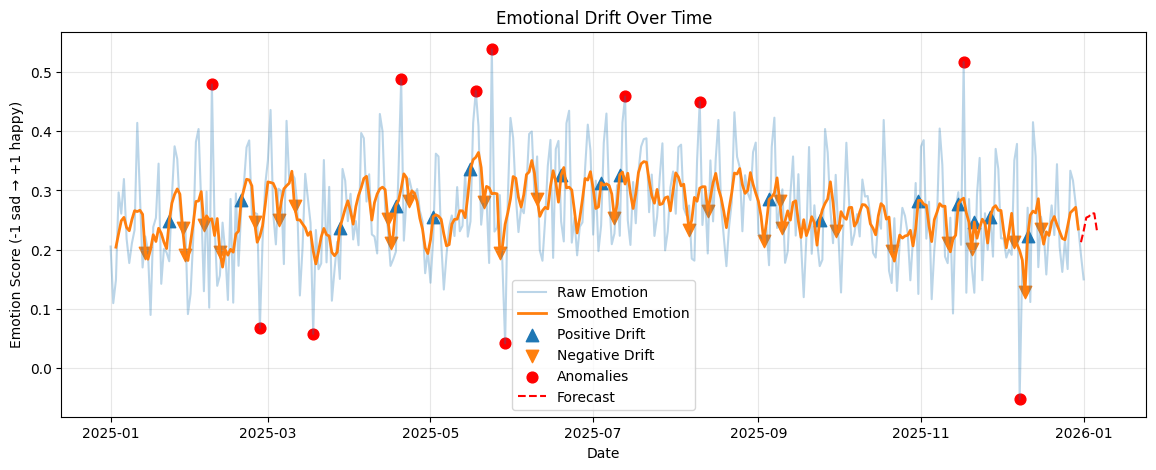

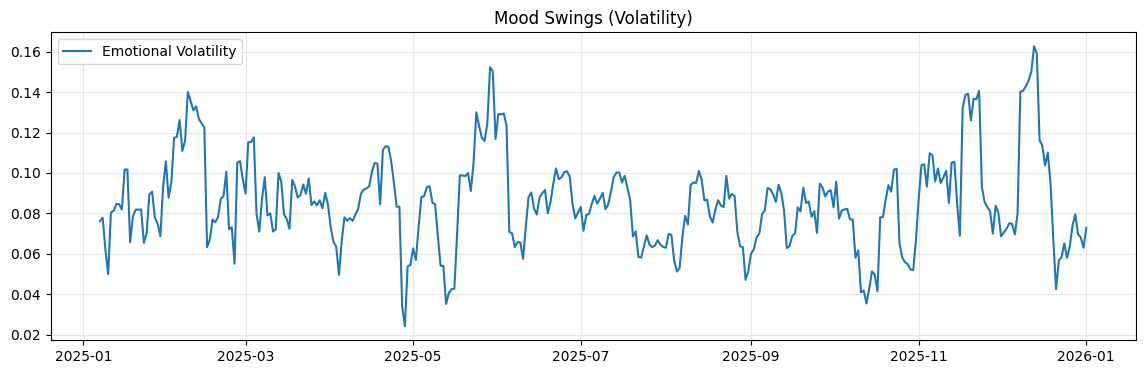


📊 EMOTIONAL INSIGHTS
Average mood: 0.264
Most positive day: 2025-05-24
Most negative day: 2025-12-08

Positive drift events: 16
Negative drift events: 27

Emotional anomalies: 11

🔮 Next 7 days emotional forecast:
[0.213 0.232 0.254 0.256 0.262 0.261 0.232]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from tbats import TBATS
import warnings
warnings.filterwarnings("ignore")
print("="*60)
print("🧠 EMOTIONAL DRIFT ANALYSIS")
print("="*60)

# =========================
# LOAD DATA
# =========================
df = pd.read_csv('full_processed_listening_data.csv')
df['datetime'] = pd.to_datetime(df['datetime'])

# =========================
# STEP 1: MAP EMOTIONS → NUMBERS
# =========================
emotion_map = {
    'happy': 1.0,
    'party': 0.8,
    'energetic': 0.6,
    'romantic': 0.4,
    'chill': 0.2,
    'calm': 0.0,
    'focus': -0.2,
    'sad': -1.0
}

df['emotion_score'] = df['emotion'].map(emotion_map)

# =========================
# STEP 2: DAILY AGGREGATION
# =========================
df['date'] = df['datetime'].dt.date

daily = df.groupby('date').agg({
    'emotion_score': 'mean',
    'emotion': 'count'
}).rename(columns={'emotion': 'total_tracks'}).reset_index()

daily['date'] = pd.to_datetime(daily['date'])
daily.set_index('date', inplace=True)

# fill missing days
daily = daily.asfreq('D')

# interpolate missing emotion scores
daily['emotion_score'] = daily['emotion_score'].interpolate()

# =========================
# STEP 3: SMOOTH SIGNAL
# =========================
daily['smooth'] = daily['emotion_score'].rolling(5, center=True).mean()

# =========================
# STEP 4: DRIFT (TREND CHANGE)
# =========================
daily['drift'] = daily['smooth'].diff()

# =========================
# STEP 5: VOLATILITY (MOOD SWINGS)
# =========================
daily['volatility'] = daily['emotion_score'].rolling(7).std()

# =========================
# STEP 6: DETECT DRIFT EVENTS
# =========================
drift_threshold = daily['drift'].std() * 1.5   ####################### ??

daily['positive_drift'] = daily['drift'] > drift_threshold
daily['negative_drift'] = daily['drift'] < -drift_threshold

# =========================
# STEP 7: DETECT ANOMALOUS MOOD
# =========================
median = np.median(daily['emotion_score'])
mad = np.median(np.abs(daily['emotion_score'] - median)) + 1e-6

z_score = 0.6745 * (daily['emotion_score'] - median) / mad

threshold = np.percentile(np.abs(z_score), 97)

daily['emotion_anomaly'] = np.abs(z_score) > threshold

# =========================
# STEP 8: TBATS FORECAST (OPTIONAL)
# =========================
series = daily['smooth'].dropna()

model = TBATS(
    seasonal_periods=[7],
    use_arma_errors=False
).fit(series.values)

forecast = model.forecast(steps=7)

future_dates = pd.date_range(series.index[-1] + timedelta(days=1), periods=7)

# =========================
# STEP 9: PLOTS
# =========================

# 🎯 MAIN EMOTION TREND
plt.figure(figsize=(14,5))

plt.plot(daily.index, daily['emotion_score'], alpha=0.3, label='Raw Emotion')
plt.plot(daily.index, daily['smooth'], linewidth=2, label='Smoothed Emotion')

plt.scatter(daily.index[daily['positive_drift']],
            daily['smooth'][daily['positive_drift']],
            label='Positive Drift', marker='^', s=80)

plt.scatter(daily.index[daily['negative_drift']],
            daily['smooth'][daily['negative_drift']],
            label='Negative Drift', marker='v', s=80)

plt.scatter(daily.index[daily['emotion_anomaly']],
            daily['emotion_score'][daily['emotion_anomaly']],
            color='red', label='Anomalies', s=60)

plt.plot(future_dates, forecast, 'r--', label='Forecast')

plt.title("Emotional Drift Over Time")
plt.ylabel("Emotion Score (-1 sad → +1 happy)")
plt.xlabel("Date")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 🎯 VOLATILITY PLOT
plt.figure(figsize=(14,4))
plt.plot(daily.index, daily['volatility'], label='Emotional Volatility')
plt.title("Mood Swings (Volatility)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# =========================
# STEP 10: INSIGHTS
# =========================
print("\n📊 EMOTIONAL INSIGHTS")

print(f"Average mood: {daily['emotion_score'].mean():.3f}")
print(f"Most positive day: {daily['emotion_score'].idxmax().date()}")
print(f"Most negative day: {daily['emotion_score'].idxmin().date()}")

print(f"\nPositive drift events: {daily['positive_drift'].sum()}")
print(f"Negative drift events: {daily['negative_drift'].sum()}")

print(f"\nEmotional anomalies: {daily['emotion_anomaly'].sum()}")

print("\n🔮 Next 7 days emotional forecast:")
print(np.round(forecast, 3))

In [ ]:
# Dates with positive/negative drift
pos_drift_dates = daily.index[daily['positive_drift']]
neg_drift_dates = daily.index[daily['negative_drift']]

# Dates with emotion anomalies
anomaly_dates = daily.index[daily['emotion_anomaly']]

In [ ]:
# Ensure df['date'] is datetime, matching daily.index
df['date'] = pd.to_datetime(df['date'])

# Then filter for positive/negative drift or anomalies
pos_drift_tracks = df[df['date'].isin(pos_drift_dates)]
neg_drift_tracks = df[df['date'].isin(neg_drift_dates)]
anomaly_tracks = df[df['date'].isin(anomaly_dates)]

# Show results
print("\n✅ Positive Drift Tracks")
print(pos_drift_tracks[['datetime', 'track_info', 'emotion', 'emotion_score']])

print("\n❌ Negative Drift Tracks")
print(neg_drift_tracks[['datetime', 'track_info', 'emotion', 'emotion_score']])

print("\n🚨 Anomalous Emotion Tracks")
print(anomaly_tracks[['datetime', 'track_info', 'emotion', 'emotion_score']])


✅ Positive Drift Tracks
                 datetime                                         track_info  \
6109  2025-01-23 00:22:46  {'artist': 'Nessa Barrett', 'track': 'Pain', '...   
6110  2025-01-23 00:26:31  {'artist': 'Freestyle', 'track': 'Before I Let...   
6111  2025-01-23 00:31:24  {'artist': 'Loveable Wholes, mage tears', 'tra...   
6112  2025-01-23 00:33:33  {'artist': 'Hudson Westbrook', 'track': '5 to ...   
6113  2025-01-23 02:37:00  {'artist': 'Gipsy Kings', 'track': 'No Volvere...   
...                   ...                                                ...   
88460 2025-12-11 20:02:45  {'artist': 'Wadih El Cheikh', 'track': 'خطر عا...   
88461 2025-12-11 20:05:45  {'artist': 'Jay Wheeler, Myke Towers, Rauw Ale...   
88462 2025-12-11 20:12:10  {'artist': 'Mazdem', 'track': 'Freezing', 'sta...   
88463 2025-12-11 20:14:53  {'artist': 'crwn, Jess Connelly', 'track': 'Wa...   
88464 2025-12-11 20:18:42  {'artist': 'Billy Idol', 'track': 'Rebel Yell'...   

         emoti

In [ ]:
# Top positive contributors to positive drift
top_pos = pos_drift_tracks.sort_values('emotion_score', ascending=False).head(10)
print("\nTop Positive Tracks (Drift)")
print(top_pos[['datetime', 'track_info', 'emotion', 'emotion_score']])

# Top negative contributors to negative drift
top_neg = neg_drift_tracks.sort_values('emotion_score').head(10)
print("\nTop Negative Tracks (Drift)")
print(top_neg[['datetime', 'track_info', 'emotion', 'emotion_score']])



Top Positive Tracks (Drift)
                 datetime                                         track_info  \
35497 2025-05-16 15:42:15  {'artist': 'Lemon Demon', 'track': 'Geocities ...   
31469 2025-05-02 15:29:37  {'artist': 'Ray LaMontagne', 'track': 'You Are...   
47116 2025-07-04 09:15:26  {'artist': 'Archetypes Collide', 'track': 'Too...   
88274 2025-12-11 22:42:58  {'artist': 'Hakim, Don Omar', 'track': 'Tigi T...   
82186 2025-11-15 22:23:15  {'artist': 'Mariya Takeuchi', 'track': 'Shiawa...   
31452 2025-05-02 08:11:22  {'artist': 'Bad Bunny', 'track': 'Agosto', 'st...   
82190 2025-11-15 22:38:04  {'artist': 'Walter Murphy', 'track': 'A Fifth ...   
82191 2025-11-15 22:41:08  {'artist': 'Bob Marley & The Wailers, Chineke!...   
47081 2025-07-04 23:07:42  {'artist': 'SEGA SOUND TEAM', 'track': 'Sonic ...   
47075 2025-07-04 10:53:07  {'artist': 'L D R U, Paige IV', 'track': 'Keep...   

      emotion  emotion_score  
35497   happy            1.0  
31469   happy            1.0